# 🌍⚡ Kuis PBA 2026 — NER, Sentimen & TF-IDF pada Artikel EV (Electric Vehicle)

## Muhammad Iqbal Baiduri Yamani — 5026221103

---

### 🎯 Tujuan
Melakukan scraping **5 artikel** tentang **Electric Vehicle (EV)** dan perubahan iklim, lalu menganalisis:
1. 🏷️ **Named Entity Recognition (NER)** — menggunakan spaCy
2. 💬 **Sentiment Analysis** — menggunakan TextBlob
3. 📊 **TF-IDF Analysis** — menggunakan scikit-learn

### Workflow:
1. 📥 Scrape 5 artikel EV/Climate dari URL yang ditentukan (newspaper3k)
2. 🧹 Preprocessing teks
3. 🏷️ NER: Temukan entitas (PERSON, ORG, GPE, DATE, dll.)
4. 💬 Sentimen: Hitung polaritas tiap artikel
5. 📊 TF-IDF: Identifikasi kata kunci paling penting

## 📦 Install & Import Libraries

In [21]:
%pip install -q newspaper3k spacy textblob scikit-learn matplotlib pandas lxml_html_clean

Note: you may need to restart the kernel to use updated packages.


c:\Users\mikba\Downloads\Documents\PBA\PBA\.venv\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=7>
  res = process_handler(cmd, _system_body)
c:\Users\mikba\Downloads\Documents\PBA\PBA\.venv\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=5>
  res = process_handler(cmd, _system_body)
c:\Users\mikba\Downloads\Documents\PBA\PBA\.venv\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  res = process_handler(cmd, _system_body)


In [22]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True)
print("✅ Model spaCy 'en_core_web_sm' berhasil didownload!")

✅ Model spaCy 'en_core_web_sm' berhasil didownload!


In [23]:
import pandas as pd
import re
import spacy
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from newspaper import Article
from IPython.display import display

nlp = spacy.load("en_core_web_sm")

print("✅ Libraries berhasil diimport!")

✅ Libraries berhasil diimport!


## 🌐 Scraping 5 Artikel EV & Climate Change

Mengambil **5 artikel** yang sudah ditentukan mengenai Electric Vehicle dan dampaknya terhadap perubahan iklim menggunakan **newspaper3k** untuk mengekstrak isi lengkap artikel.

> ⏱️ Proses scraping memakan waktu beberapa detik per artikel.

In [37]:
# Daftar 5 artikel EV & Climate Change yang akan dianalisis
URLS = [
    "https://blog.ucs.org/dave-reichmuth/electric-vehicles-help-combat-climate-change-heres-why/",
    "https://www.epa.gov/greenvehicles/electric-vehicle-myths",
    "https://climate.mit.edu/explainers/electric-vehicles",
    "https://cayimby.org/map/why-evs-alone-wont-fix-climate-change/",
    "https://www.carbonclick.com/news-views/the-environmental-impact-of-current-generation-electric-vehicles-manufacturing-and-running",
]

print(f"📋 {len(URLS)} artikel akan di-scrape:\n")
for i, url in enumerate(URLS, 1):
    print(f"  {i}. {url}")

📋 5 artikel akan di-scrape:

  1. https://blog.ucs.org/dave-reichmuth/electric-vehicles-help-combat-climate-change-heres-why/
  2. https://www.epa.gov/greenvehicles/electric-vehicle-myths
  3. https://climate.mit.edu/explainers/electric-vehicles
  4. https://cayimby.org/map/why-evs-alone-wont-fix-climate-change/
  5. https://www.carbonclick.com/news-views/the-environmental-impact-of-current-generation-electric-vehicles-manufacturing-and-running


In [38]:
articles_data = []

for i, url in enumerate(URLS, 1):
    print(f"📥 [{i}] Mengekstrak: {url[:70]}...")
    try:
        art = Article(url)
        art.download()
        art.parse()
        if len(art.text.strip()) < 100:
            print(f"   ⚠️ Artikel terlalu pendek, skip.")
            continue
        articles_data.append({
            'title': art.title,
            'url': url,
            'text': art.text.strip(),
        })
        print(f"   ✅ Berhasil! ({len(art.text):,} karakter)")
    except Exception as e:
        print(f"   ❌ Gagal: {str(e)[:80]}")

print(f"\n🎉 Total artikel berhasil diekstrak: {len(articles_data)}/{len(URLS)}")

📥 [1] Mengekstrak: https://blog.ucs.org/dave-reichmuth/electric-vehicles-help-combat-clim...
   ✅ Berhasil! (8,883 karakter)
📥 [2] Mengekstrak: https://www.epa.gov/greenvehicles/electric-vehicle-myths...
   ✅ Berhasil! (13,739 karakter)
📥 [3] Mengekstrak: https://climate.mit.edu/explainers/electric-vehicles...
   ✅ Berhasil! (4,792 karakter)
📥 [4] Mengekstrak: https://cayimby.org/map/why-evs-alone-wont-fix-climate-change/...
   ✅ Berhasil! (4,403 karakter)
📥 [5] Mengekstrak: https://www.carbonclick.com/news-views/the-environmental-impact-of-cur...
   ✅ Berhasil! (4,478 karakter)

🎉 Total artikel berhasil diekstrak: 5/5


## 💾 Simpan ke DataFrame & Preview

In [39]:
df = pd.DataFrame(articles_data)

# Simpan ke CSV
CSV_FILE = 'ev_climate_articles.csv'
df.to_csv(CSV_FILE, index=False)

print(f"✅ Data disimpan ke: {CSV_FILE}")
print(f"📊 Shape: {df.shape}\n")

print("👁️ Preview artikel:")
for i, row in df.iterrows():
    print(f"\n{'='*70}")
    print(f"📰 Artikel {i+1}: {row['title'][:70]}")
    print(f"🔗 URL    : {row['url'][:80]}")
    print(f"📝 Cuplikan: {row['text'][:200]}...")

✅ Data disimpan ke: ev_climate_articles.csv
📊 Shape: (5, 3)

👁️ Preview artikel:

📰 Artikel 1: Electric Vehicles Help Combat Climate Change, Here’s Why.
🔗 URL    : https://blog.ucs.org/dave-reichmuth/electric-vehicles-help-combat-climate-change
📝 Cuplikan: EDITORIAL UPDATE (11/13/25): A more recent version of the analysis in this blog is available here.



There is tremendous uncertainty about what policies the federal government will change that will a...

📰 Artikel 2: Electric Vehicle Myths
🔗 URL    : https://www.epa.gov/greenvehicles/electric-vehicle-myths
📝 Cuplikan: EV Facts

Myth #1: Electric vehicles are worse for the climate than gasoline cars because of power plant emissions.

FACT: Electric vehicles (EVs) typically have a smaller carbon footprint than gasoli...

📰 Artikel 3: Electric Vehicles
🔗 URL    : https://climate.mit.edu/explainers/electric-vehicles
📝 Cuplikan: Electric vehicles (EVs) are a cleaner alternative to gasoline- or diesel-powered cars and trucks—both in terms

## 🧹 Preprocessing Teks

Bersihkan teks artikel dari noise: URL, tag HTML, karakter khusus, dan spasi berlebih.

In [40]:
def clean_text(text):
    """Membersihkan teks dari URL, tag HTML, karakter khusus."""
    text = str(text)
    text = re.sub(r'https?://\S+', ' ', text)           # hapus URL
    text = re.sub(r'<[^>]+>', ' ', text)                 # hapus HTML tags
    text = re.sub(r'[^a-zA-Z0-9\s.,!?\'-]', ' ', text)  # hapus karakter aneh
    text = re.sub(r'\s+', ' ', text).strip()             # normalisasi spasi
    return text

df['text_clean'] = df['text'].apply(clean_text)

print("✅ Preprocessing selesai!\n")
for i, row in df.iterrows():
    print(f"📰 Artikel {i+1} — {len(row['text_clean']):,} karakter setelah cleaning")
    print(f"   Cuplikan: {row['text_clean'][:150]}...\n")

✅ Preprocessing selesai!

📰 Artikel 1 — 8,824 karakter setelah cleaning
   Cuplikan: EDITORIAL UPDATE 11 13 25 A more recent version of the analysis in this blog is available here. There is tremendous uncertainty about what policies th...

📰 Artikel 2 — 13,576 karakter setelah cleaning
   Cuplikan: EV Facts Myth 1 Electric vehicles are worse for the climate than gasoline cars because of power plant emissions. FACT Electric vehicles EVs typically ...

📰 Artikel 3 — 4,724 karakter setelah cleaning
   Cuplikan: Electric vehicles EVs are a cleaner alternative to gasoline- or diesel-powered cars and trucks both in terms of harmful air pollution, and the greenho...

📰 Artikel 4 — 4,363 karakter setelah cleaning
   Cuplikan: MAP Issue Primer Why EVs Alone Won t Fix Climate Change Electric cars aren t enough we need to drive less. Why do we need walkable cities and better p...

📰 Artikel 5 — 4,442 karakter setelah cleaning
   Cuplikan: FAQ's What is the environmental impact of current generati

## 🏷️ Part 1: Named Entity Recognition (NER)

NER = *Named Entity Recognition* — menemukan nama orang, organisasi, lokasi, tanggal, dll. dalam teks.

Menggunakan **spaCy** (`en_core_web_sm`) untuk mengekstrak entitas dari setiap artikel, mirip pendekatan **Climate-IBM NER**.

| Tag     | Deskripsi                |
|---------|--------------------------|
| PERSON  | Nama Orang               |
| ORG     | Organisasi               |
| GPE     | Negara / Kota            |
| DATE    | Tanggal / Waktu          |
| MONEY   | Nilai Uang               |
| PERCENT | Persentase               |
| PRODUCT | Produk                   |
| EVENT   | Acara / Peristiwa        |

In [41]:
all_entities = []

for i, row in df.iterrows():
    doc = nlp(row['text_clean'])
    print(f"\n{'='*70}")
    print(f"📰 Artikel {i+1}: {row['title'][:60]}")
    print(f"{'='*70}")

    if not doc.ents:
        print("   (Tidak ada entitas terdeteksi)")
        continue

    print(f"\n{'Entitas':<35} {'Label':<10} {'Deskripsi'}")
    print('-' * 70)
    seen = set()
    for ent in doc.ents:
        key = (ent.text.strip(), ent.label_)
        if key not in seen:
            seen.add(key)
            all_entities.append({
                'article_id': i + 1,
                'entity': ent.text.strip(),
                'label': ent.label_,
                'description': spacy.explain(ent.label_) or ''
            })
            print(f"   {ent.text.strip():<32} {ent.label_:<10} {spacy.explain(ent.label_) or ''}")

print(f"\n🎯 Total entitas unik ditemukan: {len(all_entities)}")


📰 Artikel 1: Electric Vehicles Help Combat Climate Change, Here’s Why.

Entitas                             Label      Deskripsi
----------------------------------------------------------------------
   EDITORIAL UPDATE                 PERSON     People, including fictional
   11 13 25                         DATE       Absolute or relative dates or periods
   EV                               ORG        Companies, agencies, institutions, etc.
   US                               GPE        Countries, cities, states
   100 mile                         QUANTITY   Measurements, as of weight or distance
   one                              CARDINAL   Numerals that do not fall under another type
   Transportation                   ORG        Companies, agencies, institutions, etc.
   100                              CARDINAL   Numerals that do not fall under another type
   first                            ORDINAL    "first", "second", etc.
   only 45 percent                  PERCENT    Perc

### 🔍 Visualisasi NER — Artikel Pertama (displacy)

In [42]:
# Visualisasi NER pada 500 karakter pertama artikel pertama
sample_doc = nlp(df['text_clean'].iloc[0][:500])

print(f"📰 Visualisasi NER — Artikel 1: {df['title'].iloc[0][:50]}...\n")
spacy.displacy.render(sample_doc, style="ent", jupyter=True)

📰 Visualisasi NER — Artikel 1: Electric Vehicles Help Combat Climate Change, Here...



### 📊 Ringkasan Distribusi Entitas NER

Hitung frekuensi setiap jenis entitas (label) yang ditemukan di seluruh 5 artikel.

📊 Distribusi Label NER:

label
ORG         61
CARDINAL    56
DATE        47
QUANTITY    19
PERSON      11
GPE         11
PERCENT      7
ORDINAL      6
PRODUCT      4
TIME         3
NORP         2
LAW          2
FAC          1
MONEY        1
EVENT        1


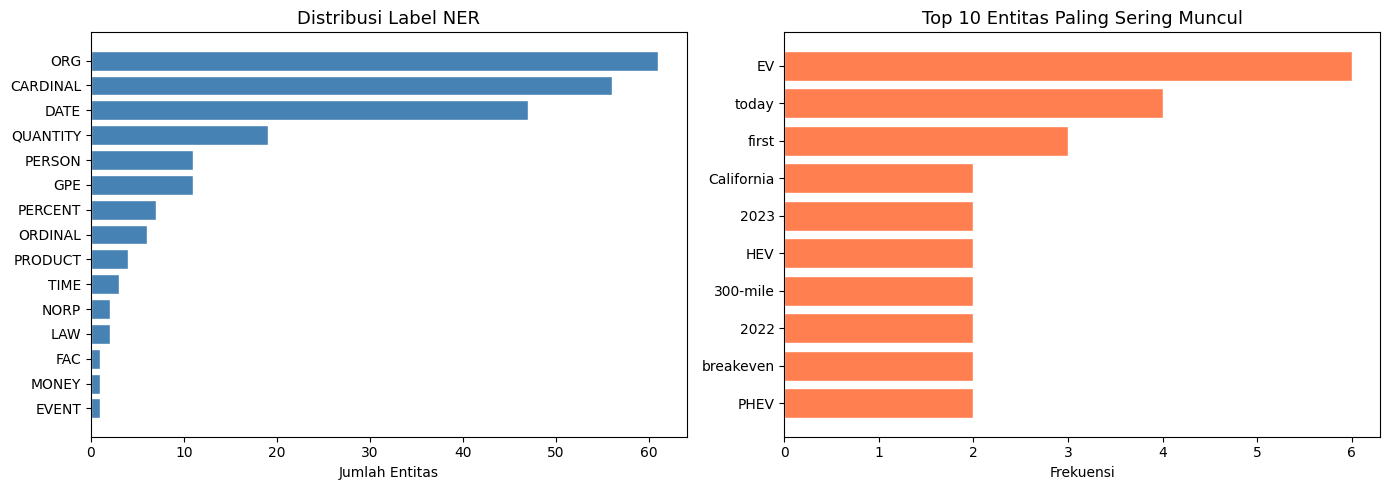


✅ Hasil NER disimpan ke 'ev_climate_ner_results.csv'


In [43]:
df_ner = pd.DataFrame(all_entities)

# Distribusi label
label_counts = df_ner['label'].value_counts()
print("📊 Distribusi Label NER:\n")
print(label_counts.to_string())

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart distribusi label
axes[0].barh(label_counts.index[::-1], label_counts.values[::-1], color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Label NER', fontsize=13)
axes[0].set_xlabel('Jumlah Entitas')

# Top 10 entitas paling sering
top_entities = df_ner.groupby('entity').size().sort_values(ascending=False).head(10)
axes[1].barh(top_entities.index[::-1], top_entities.values[::-1], color='coral', edgecolor='white')
axes[1].set_title('Top 10 Entitas Paling Sering Muncul', fontsize=13)
axes[1].set_xlabel('Frekuensi')

plt.tight_layout()
plt.show()

# Simpan ke CSV
df_ner.to_csv('ev_climate_ner_results.csv', index=False)
print("\n✅ Hasil NER disimpan ke 'ev_climate_ner_results.csv'")

## 💬 Part 2: Sentiment Analysis (TextBlob)

**TextBlob** menganalisis sentimen teks berbasis leksikon Inggris. Nilai polaritas:
- **> 0** → Positif
- **= 0** → Netral
- **< 0** → Negatif

Karena artikel dalam bahasa Inggris, TextBlob bekerja optimal di sini.

In [44]:
def analyze_sentiment(text):
    """Analisis polaritas sentimen menggunakan TextBlob."""
    blob = TextBlob(str(text))
    return blob.sentiment.polarity

def categorize_sentiment(polarity):
    """Kategorisasi polaritas menjadi label."""
    if polarity > 0.05:
        return 'Positif'
    elif polarity < -0.05:
        return 'Negatif'
    else:
        return 'Netral'

# Terapkan ke setiap artikel
df['polarity'] = df['text_clean'].apply(analyze_sentiment)
df['subjectivity'] = df['text_clean'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)
df['sentiment'] = df['polarity'].apply(categorize_sentiment)

print("💬 Hasil Sentiment Analysis:\n")
print(f"{'No.':<5} {'Sentimen':<10} {'Polarity':>10} {'Subjectivity':>13}   {'Judul Artikel'}")
print('-' * 90)
for i, row in df.iterrows():
    print(f"{i+1:<5} {row['sentiment']:<10} {row['polarity']:>10.4f} {row['subjectivity']:>13.4f}   {row['title'][:45]}")

💬 Hasil Sentiment Analysis:

No.   Sentimen     Polarity  Subjectivity   Judul Artikel
------------------------------------------------------------------------------------------
1     Positif        0.1189        0.4071   Electric Vehicles Help Combat Climate Change,
2     Positif        0.0790        0.4294   Electric Vehicle Myths
3     Positif        0.1692        0.4926   Electric Vehicles
4     Positif        0.1154        0.4479   Why EVs Alone Won’t Fix Climate Change
5     Positif        0.2078        0.5091   The environmental impact of current-generatio


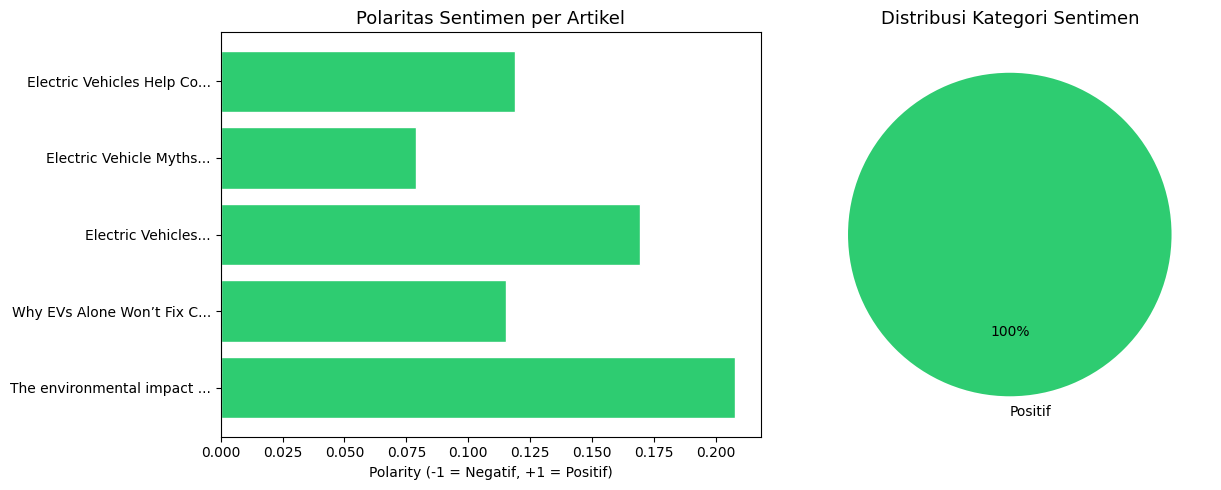

In [45]:
# Visualisasi Sentimen
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart: Polarity per artikel
colors = ['#2ecc71' if s == 'Positif' else '#e74c3c' if s == 'Negatif' else '#95a5a6'
          for s in df['sentiment']]
short_titles = [t[:25] + '...' for t in df['title']]

axes[0].barh(short_titles[::-1], df['polarity'].values[::-1],
             color=colors[::-1], edgecolor='white')
axes[0].axvline(x=0, color='black', linestyle='--', alpha=0.3)
axes[0].set_title('Polaritas Sentimen per Artikel', fontsize=13)
axes[0].set_xlabel('Polarity (-1 = Negatif, +1 = Positif)')

# Pie chart: Distribusi kategori sentimen
sent_counts = df['sentiment'].value_counts()
pie_colors = {'Positif': '#2ecc71', 'Negatif': '#e74c3c', 'Netral': '#95a5a6'}
axes[1].pie(sent_counts.values,
            labels=sent_counts.index,
            autopct='%1.0f%%',
            colors=[pie_colors.get(s, '#bdc3c7') for s in sent_counts.index],
            startangle=90)
axes[1].set_title('Distribusi Kategori Sentimen', fontsize=13)

plt.tight_layout()
plt.show()

## 📊 Part 3: Analisis TF-IDF (Term Frequency–Inverse Document Frequency)

TF-IDF mengukur **seberapa penting suatu kata** dalam satu dokumen relatif terhadap seluruh koleksi dokumen.

- **TF tinggi** → kata sering muncul di dokumen tersebut
- **IDF tinggi** → kata jarang muncul di dokumen lain (lebih unik/penting)
- **TF-IDF tinggi** → kata yang benar-benar khas untuk dokumen tersebut

In [46]:
# Fit TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    max_features=50,
    stop_words='english',
    ngram_range=(1, 2),    # unigram + bigram
    min_df=1,
    max_df=0.95,
)

tfidf_matrix = vectorizer.fit_transform(df['text_clean'])
feature_names = vectorizer.get_feature_names_out()

print(f"📊 TF-IDF Matrix shape: {tfidf_matrix.shape}")
print(f"   ({tfidf_matrix.shape[0]} dokumen × {tfidf_matrix.shape[1]} fitur)\n")

# Top 10 kata kunci global (rata-rata TF-IDF tertinggi)
import numpy as np
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[::-1][:15]

print("🔑 Top 15 Kata Kunci (rata-rata TF-IDF tertinggi):\n")
print(f"{'No.':<5} {'Kata/Frasa':<30} {'Mean TF-IDF':>12}")
print('-' * 50)
for rank, idx in enumerate(top_idx, 1):
    print(f"{rank:<5} {feature_names[idx]:<30} {mean_tfidf[idx]:>12.4f}")

📊 TF-IDF Matrix shape: (5, 50)
   (5 dokumen × 50 fitur)

🔑 Top 15 Kata Kunci (rata-rata TF-IDF tertinggi):

No.   Kata/Frasa                      Mean TF-IDF
--------------------------------------------------
1     gasoline                             0.2117
2     electricity                          0.1867
3     batteries                            0.1652
4     charging                             0.1433
5     gas                                  0.1407
6     ice                                  0.1356
7     driving                              0.1347
8     need                                 0.1314
9     powered                              0.1180
10    grid                                 0.1121
11    reduce                               0.1087
12    battery                              0.1073
13    recycling                            0.1009
14    electric vehicle                     0.1007
15    making                               0.1005


C:\Users\mikba\AppData\Local\Temp\ipykernel_48240\509808576.py:23: UserWarning: Glyph 128240 (\N{NEWSPAPER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mikba\AppData\Local\Temp\ipykernel_48240\509808576.py:23: UserWarning: Glyph 128240 (\N{NEWSPAPER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mikba\AppData\Local\Temp\ipykernel_48240\509808576.py:23: UserWarning: Glyph 128240 (\N{NEWSPAPER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mikba\AppData\Local\Temp\ipykernel_48240\509808576.py:23: UserWarning: Glyph 128240 (\N{NEWSPAPER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mikba\AppData\Local\Temp\ipykernel_48240\509808576.py:23: UserWarning: Glyph 128240 (\N{NEWSPAPER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mikba\AppData\Local\Temp\ipykernel_48240\509808576.py:24: UserWarning: Glyph 128240 (\N{NEWSPAPER}) missing from font(s) DejaVu Sans.
  plt.savefig("ev_climate_tfidf_top_w

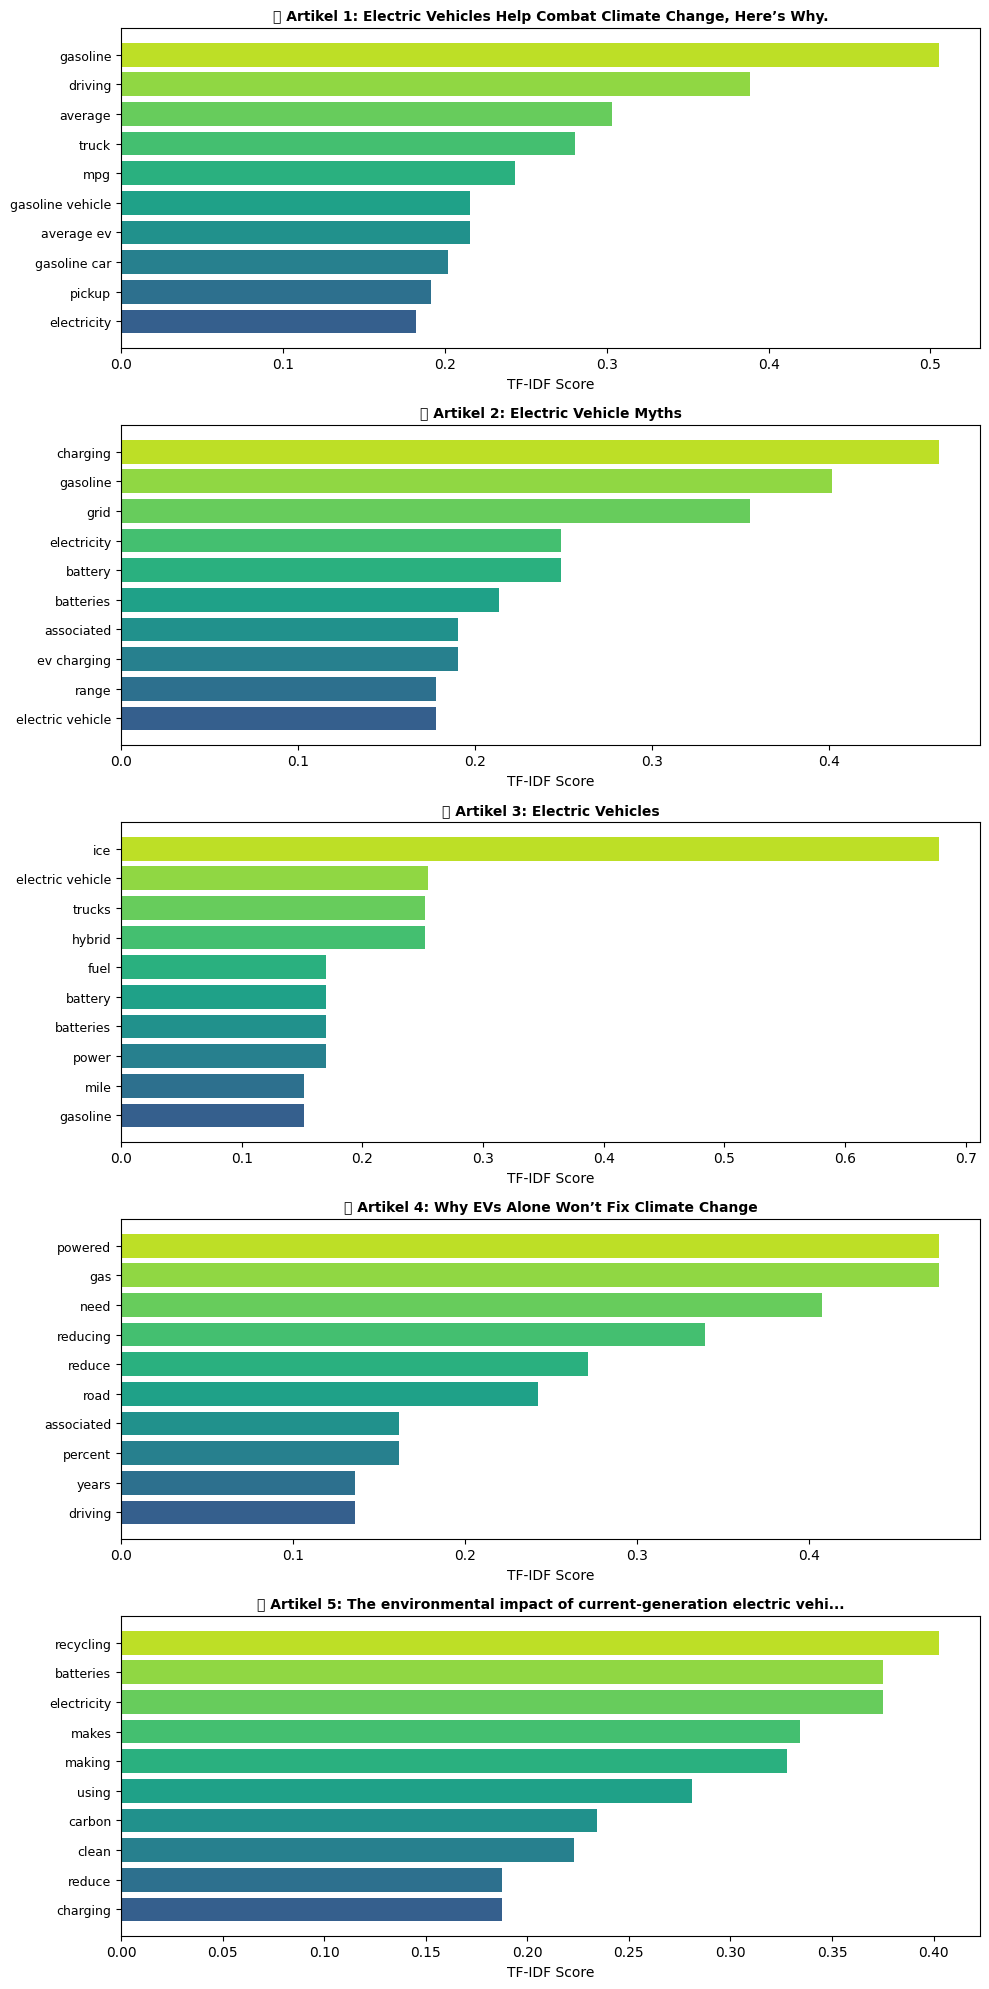


💾 Grafik tersimpan → ev_climate_tfidf_top_words.png


In [47]:
# 📈 Visualisasi: Top 10 TF-IDF per Artikel
fig, axes = plt.subplots(len(df), 1, figsize=(10, 4 * len(df)))

if len(df) == 1:
    axes = [axes]

for i, (idx, row) in enumerate(df.iterrows()):
    scores = tfidf_matrix[i].toarray().flatten()
    top_n = 10
    top_indices = scores.argsort()[-top_n:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    top_scores = [scores[j] for j in top_indices]

    ax = axes[i]
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
    ax.barh(range(top_n), top_scores[::-1], color=colors)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_words[::-1], fontsize=9)
    title = row['title'][:60] + '...' if len(row['title']) > 60 else row['title']
    ax.set_title(f"📰 Artikel {i+1}: {title}", fontsize=10, fontweight='bold')
    ax.set_xlabel("TF-IDF Score")

plt.tight_layout()
plt.savefig("ev_climate_tfidf_top_words.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Grafik tersimpan → ev_climate_tfidf_top_words.png")

---

## ✅ Kesimpulan & Rangkuman

### 📝 Ringkasan Analisis

Notebook ini melakukan **scraping**, **NER**, **Sentiment Analysis**, dan **TF-IDF** terhadap **5 artikel berbahasa Inggris** tentang **Electric Vehicle (EV) & Climate Change**.

---

### 🔍 1. Scraping (newspaper3k)

- Berhasil mengekstrak konten dari **5 URL** yang ditentukan secara manual (tanpa random search).
- Artikel berasal dari sumber terpercaya: **UCS Blog, EPA, MIT Climate, CAYIMBY, CarbonClick**.
- Panjang teks bervariasi: terpanjang **13.739 karakter** (EPA — Electric Vehicle Myths), terpendek **4.403 karakter** (CAYIMBY).

### 🏷️ 2. Named Entity Recognition (NER — spaCy)

- Total **232 entitas** terdeteksi dari 5 artikel.
- **Top 3 label**: ORG (61), CARDINAL (56), DATE (47) — menunjukkan artikel banyak menyebut organisasi, angka statistik, dan referensi waktu.
- **Entitas paling sering muncul**: *EV* (6×), *today* (4×), *first* (3×), *California* (2×), *2023* (2×), *HEV* (2×).
- Label GPE (11) mengindikasikan diskusi geopolitik (California, negara-negara produsen EV).
- Label PERCENT (7) menunjukkan artikel kaya data kuantitatif (emisi, efisiensi, dll.).

### 💬 3. Sentiment Analysis (TextBlob)

- **100% artikel bersentimen Positif** (semua polarity > 0).
- Rentang polarity: **0.079** (Electric Vehicle Myths — paling netral/informatif) s.d. **0.208** (CarbonClick — paling optimis).
- Subjectivity rata-rata **~0.45** (lebih ke arah objektif/faktual), sesuai dengan sifat artikel saintifik/edukatif.
- Artikel "Why EVs Alone Won't Fix Climate Change" tetap positif (0.115) meski judulnya terkesan kritis — kontennya tetap konstruktif.

| Artikel | Polarity | Subjectivity | Sentimen |
|---------|----------|-------------|----------|
| UCS Blog — EV Help Combat Climate Change | 0.119 | 0.407 | Positif |
| EPA — Electric Vehicle Myths | 0.079 | 0.429 | Positif |
| MIT Climate — Electric Vehicles | 0.169 | 0.493 | Positif |
| CAYIMBY — Why EVs Alone Won't Fix | 0.115 | 0.448 | Positif |
| CarbonClick — Environmental Impact | 0.208 | 0.509 | Positif |

### 📊 4. TF-IDF Analysis (scikit-learn)

- **50 fitur** diekstrak dari 5 dokumen menggunakan `TfidfVectorizer`.
- **Top 5 kata kunci global** (rata-rata TF-IDF tertinggi):
  1. **gasoline** (0.212) — perbandingan EV vs kendaraan bensin mendominasi diskusi
  2. **electricity** (0.187) — sumber energi EV sebagai topik sentral
  3. **batteries** (0.165) — teknologi baterai jadi fokus utama
  4. **charging** (0.143) — infrastruktur pengisian menjadi concern utama
  5. **gas** (0.141) — emisi gas rumah kaca & bahan bakar fosil
- **Kata kunci unik per artikel** menunjukkan fokus yang berbeda-beda:
  - Artikel 1 (UCS): *gasoline, driving, mpg* → perbandingan efisiensi bahan bakar
  - Artikel 2 (EPA): *charging, grid* → mitos & fakta infrastruktur
  - Artikel 3 (MIT): *ice, trucks, hybrid* → perbandingan jenis kendaraan
  - Artikel 4 (CAYIMBY): *powered, gas, reducing* → solusi pengurangan emisi
  - Artikel 5 (CarbonClick): *recycling, batteries, electricity* → siklus hidup & dampak lingkungan

---

### 🎯 Insight Utama

> Kelima artikel menunjukkan **perspektif positif-konstruktif** terhadap EV sebagai solusi perubahan iklim, meskipun tetap mengakui tantangan (infrastruktur charging, daur ulang baterai, ketergantungan grid listrik). Analisis TF-IDF mengkonfirmasi bahwa diskusi EV sangat **berpusat pada perbandingan dengan kendaraan bensin (gasoline)** dan **teknologi baterai/pengisian** sebagai faktor kunci adopsi.

---

### 📚 Tools & Libraries yang Digunakan

| Library | Fungsi |
|---------|--------|
| `newspaper3k` | Ekstraksi konten artikel dari URL |
| `spaCy (en_core_web_sm)` | Named Entity Recognition (NER) |
| `TextBlob` | Sentiment Analysis (polarity & subjectivity) |
| `scikit-learn` | TF-IDF Vectorizer |
| `matplotlib` | Visualisasi grafik |
| `pandas` | Manipulasi dan analisis data |